In [1]:
import os
import torch
import torch.nn as nn
from torch_geometric.loader import DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

from src.train_gat import FloorplanGNN, ZarrDataset, CLASS_WEIGHTS
from src.utils import download_and_extract_state_dict, get_vocab

/home/sagemaker-user/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%store -r

In [3]:
val_indices = np.load("val_indices.npy")

In [4]:
metadata_df = pd.read_parquet("metadata.parquet")

In [5]:
zarr_path = f"{s3_project_prefix}/store/data.zarr"

In [6]:
val_dataset   = ZarrDataset(zarr_path, val_indices)

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [8]:
val_loader = DataLoader(
		val_dataset,
		batch_size=64,
		shuffle=False,
		num_workers=min(16, os.cpu_count()),
		pin_memory=True,
	)
	
model = FloorplanGNN(dropout=0).to(device)

In [9]:
state_dict_s3 = "s3://sagemaker-us-east-1-298748835671/floorplan-generator/models/model_artifacts/gat/pipelines-c4br77puqmrt-TrainGATModel-BPP2bxHzOh/output/model.tar.gz"
state_dict_path = download_and_extract_state_dict(state_dict_s3)
		
model.load_state_dict(torch.load(state_dict_path, map_location=device))

Extracting to ./extracted_model ...
Found model_best.pth at ./extracted_model/model_best.pth


<All keys matched successfully>

In [10]:
model.eval()
val_loss = 0.0
all_preds, all_labels = [], []

criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS.to(device))

with torch.no_grad():
    for batch in val_loader:
        batch = batch.to(device)
        logits = model(batch)
        val_loss += criterion(logits, batch.y).item()
        all_preds.append(logits.argmax(dim=-1).cpu())
        all_labels.append(batch.y.cpu())

val_loss /= len(val_loader)
y_pred = torch.cat(all_preds).numpy()
y_true = torch.cat(all_labels).numpy()
acc = (y_pred == y_true).mean()  # node-level accuracy over the whole val set

print(f"val loss: {val_loss:.4f} | val acc: {acc:.4f} | nodes: {len(y_true)}")

val loss: 1.4945 | val acc: 0.5784 | nodes: 109603


In [11]:
# 13 room classes (drop 'External' and 'ExteriorWall', which aren't node labels)
class_names = get_vocab()["object_idx_to_name"][:13]
labels = list(range(len(class_names)))

cm = confusion_matrix(y_true, y_pred, labels=labels)
# Row-normalize so each row shows recall per true class; guard against empty rows
cm_norm = cm / np.clip(cm.sum(axis=1, keepdims=True), 1, None)

print(classification_report(y_true, y_pred, labels=labels, target_names=class_names, zero_division=0))

              precision    recall  f1-score   support

  LivingRoom       0.99      0.97      0.98     16158
  MasterRoom       0.71      0.72      0.71     16097
     Kitchen       0.65      0.44      0.52     15560
    Bathroom       0.79      0.50      0.62     19348
  DiningRoom       0.02      0.52      0.04       253
   ChildRoom       0.03      0.19      0.05       791
   StudyRoom       0.15      0.25      0.19      2923
  SecondRoom       0.71      0.28      0.41     20008
   GuestRoom       0.01      0.20      0.01       162
     Balcony       0.81      0.71      0.76     17324
    Entrance       0.01      0.30      0.03        57
     Storage       0.10      0.39      0.16       689
     Wall-in       0.02      0.55      0.04       233

    accuracy                           0.58    109603
   macro avg       0.39      0.46      0.35    109603
weighted avg       0.74      0.58      0.63    109603



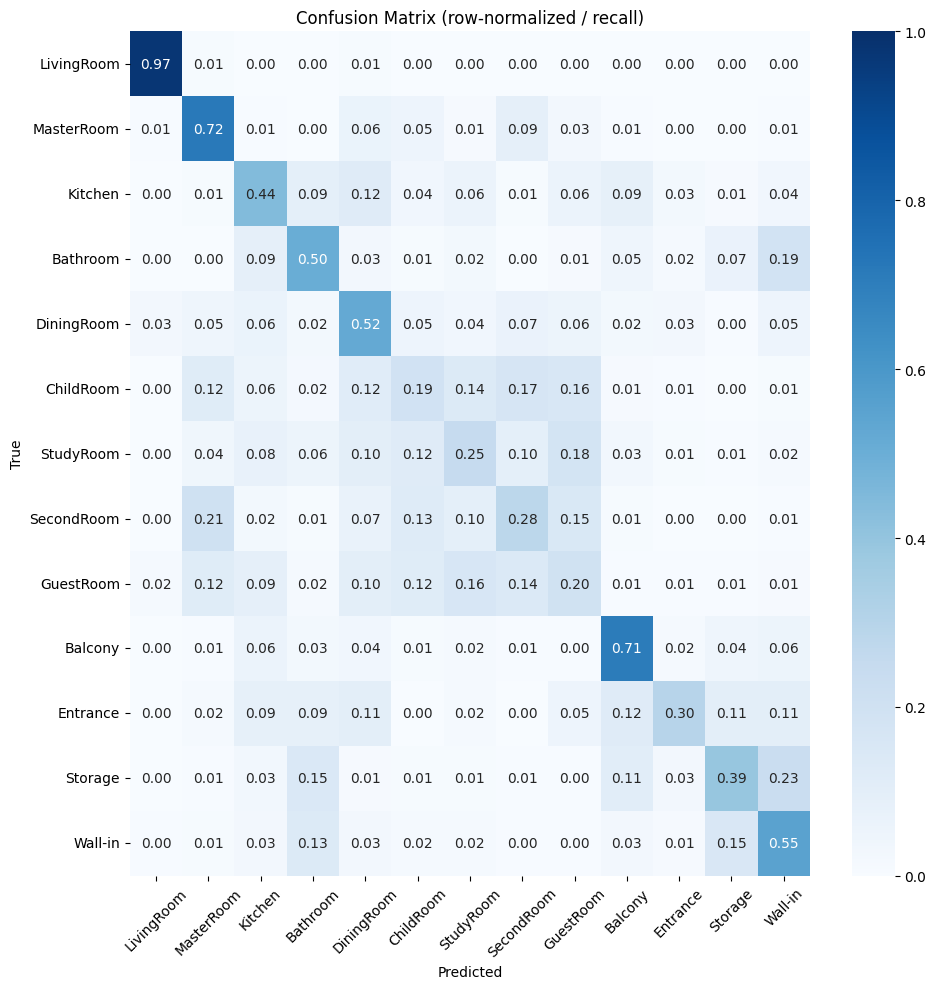

In [17]:
fig, ax = plt.subplots(figsize=(10, 10))

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title("Confusion Matrix (row-normalized / recall)")

ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()